# Modeling Template

This is a template made for loading data from thousands of random Pokemon generation 9 battles from https://pokemonshowdown.com/ and using features from a csv to create models which predict the winner. 

# Outline
## Section 1: Modeling
### 1.1 Logistic Regression
    1.1.1 Baseline model
    1.1.2 Improvements
### 1.2 Decision Tree
### 1.3 Random Forest
### 1.4 
### 1.5
## Section 2: Model Comparisons
### 2.1 AUC score
### 2.2 Cross Validation Score
## Section 3: Best Model Analysis
### 3.1 ROC Curve
### 3.2 Confusion Matrix

In [1]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator,ClassifierMixin
from xgboost import XGBClassifier

In [2]:
# Load in training dataframe
path_to_train = "../data/data_cleaned.csv.zip"
full_df = pd.read_csv(path_to_train)

# Eliminate any matches where one player quits prematurely
complete_matches = full_df[(full_df['duration'] > 60) & ((full_df["p1_revealed_team_size"] > 2) | (full_df["p2_revealed_team_size"] > 2))]

# only analyze matches for which we know the players' elo ratings (so that we can use elo_diff as a feature)
train_df = complete_matches[complete_matches['p1elo0'] > 0].copy()
train_df['elo_diff'] =  train_df['p1elo0'] - train_df['p2elo0']

print(train_df.columns.tolist())

# Load in testing dataframe
# path_to_test = "<replace with path to test data csv>"
# test_df = pd.read_csv(path_to_test)
# print(test_df.columns.tolist())

['format', 'id', 'p1_win', 'ratedQ', 'n_turns', 'start_time', 'end_time', 'duration', 'p1name', 'p1side', 'p1elo0', 'p1elo1', 'p2name', 'p2side', 'p2elo0', 'p2elo1', 'type_diversity_diff', 'num_boosting_abilities_diff', 'num_move_boosters_diff', 'total_stat_diff', 'p1_total_adv', 'p1_revealed_team_size', 'p2_revealed_team_size', 'M11_name', 'M11_speciesId', 'M11_used', 'M11_gender', 'M11_shinyQ', 'M11_level', 'M11_ability', 'M11_item', 'M11_teraType', 'M11_role', 'M11_mv1', 'M11_mv2', 'M11_mv3', 'M11_mv4', 'M11_type1', 'M11_type2', 'M11_hp', 'M11_atk', 'M11_def', 'M11_spa', 'M11_spd', 'M11_spe', 'M11_off', 'M12_name', 'M12_speciesId', 'M12_used', 'M12_gender', 'M12_shinyQ', 'M12_level', 'M12_ability', 'M12_item', 'M12_teraType', 'M12_role', 'M12_mv1', 'M12_mv2', 'M12_mv3', 'M12_mv4', 'M12_type1', 'M12_type2', 'M12_hp', 'M12_atk', 'M12_def', 'M12_spa', 'M12_spd', 'M12_spe', 'M12_off', 'M13_name', 'M13_speciesId', 'M13_used', 'M13_gender', 'M13_shinyQ', 'M13_level', 'M13_ability', 'M13_i

# Section 1: Modeling
## 1.1 Logistic Regression
### 1.1.1 Baseline Model

We begin with a simple model using only one feature to predict battle outcome. Following models will add features to see if this baseline model can be improved.

In [3]:
class CustomEloPredictor(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(self, scale=400):
        self.scale = scale

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        elo_diff = X[:, 0].astype(float)
        p = 1 / (1 + 10 ** (-elo_diff / self.scale))
        return np.column_stack([1 - p, p])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        preds = (probs >= 0.5).astype(int)
        return self.classes_[preds]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

In [4]:
########## BASELINE MODEL ##########
base_feature = ["elo_diff"]
X_train_base = train_df[base_feature]
y_train = train_df["p1_win"]

custom_baseline = CustomEloPredictor()


### 1.1.2 Improvements

In [5]:
########## IMPROVED MODEL ##########
features = [
    "elo_diff",
    "p1_total_adv",
    "total_stat_diff",
    "type_diversity_diff",
    "num_move_boosters_diff",
    "num_boosting_abilities_diff"
]
X_train = train_df[features]

# preprocess = ColumnTransformer(
#     transformers=[
#         ("scaler", StandardScaler(), ["elo_diff"])
#     ],
#     remainder="passthrough"
# )
preprocess = StandardScaler()

lr_balanced = Pipeline([
    ('preprocess',preprocess),
    ('lr',LogisticRegression(max_iter=10000,C=np.inf,fit_intercept=False))
])

lr_biased = LogisticRegression(max_iter=10000,C=np.inf,fit_intercept=True)

## 1.2 Decision Tree

In [7]:
# Do a grid search for decision tree parameters
dt_param_grid = {
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 20}


In [6]:
dt = Pipeline([
    ('preprocess',preprocess),
    ('dt',DecisionTreeClassifier(
    random_state=0,
    max_depth = 3,
    min_samples_leaf= 1,
    min_samples_split= 20))
])

## 1.3 Random Forest

In [7]:
# Do a grid search for random forest parameters
rf_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_samples_leaf': 20, 'n_estimators': 500}


In [7]:
rf = Pipeline([
    ('preprocess',preprocess),
    ('rf',RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0))
])

## 1.4 Histogram-based Gradient Boosting Classification Tree

In [9]:
# Do a grid search for HistGradientBoosting parameters
hgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "max_iter": [100, 200, 500] 
}

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0),
    param_grid=hgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'max_iter': 100, 'min_samples_leaf': 20}


In [8]:
hgb = Pipeline([
    ('preprocess',preprocess),
    ('hgb',HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0))
])

## 1.5 XGBoost

In [11]:
# Do a grid search for XGBoost parameters
xgb_param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_child_weight": [5, 10, 20], 
    "n_estimators": [200, 500, 800] 
}

grid = GridSearchCV(
    XGBClassifier(random_state=0),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 200}


In [9]:
xgb = Pipeline([
    ('preprocess',preprocess),
    ('xgb',XGBClassifier(
    n_estimators=200,
    max_depth=4,
    min_child_weight=20,
    random_state=0))
])



# Section 2: Model Comparisons

## 2.1 Cross Validation Score

In [10]:
models = [
    ("custom baseline",custom_baseline,X_train_base),
    ("baseline unbiased linear regression", lr_balanced,X_train_base),
    ("full unbiased linear regression", lr_balanced,X_train[['elo_diff','p1_total_adv','num_move_boosters_diff']]),
    ("full biased linear regression", lr_biased, X_train),
    ("decision tree", dt, X_train),
    ("random forest", rf, X_train),
    ("histogram Gradient Boosting", hgb, X_train),
    ("XGBoost", xgb, X_train)
]

for i in range(len(models)):
    model_name = models[i][0]
    model = models[i][1]
    data_frame = models[i][2]
    # get cross-validation scores
    cvscore = cross_val_score(model,data_frame,y_train,cv=5,n_jobs=-1,scoring="accuracy")
    print(f"The average accuracy score for the {model_name} model is {cvscore.mean()} +/- {cvscore.std(ddof=1)}")

    # get confusion matrices
    model.fit(data_frame,y_train)
    preds = model.predict(data_frame)
    cm = confusion_matrix(y_train,preds,normalize='all')
    print(f"The confusion matrix for the {model_name} model is")
    print(cm)
    print()

The average accuracy score for the custom baseline model is 0.5213061383634695 +/- 0.0077510567675363
The confusion matrix for the custom baseline model is
[[0.30441439 0.21935868]
 [0.25933486 0.21689206]]

The average accuracy score for the baseline unbiased linear regression model is 0.5161179422853786 +/- 0.007177216280121789
The confusion matrix for the baseline unbiased linear regression model is
[[0.25644297 0.2673301 ]
 [0.21578634 0.26044059]]

The average accuracy score for the full unbiased linear regression model is 0.531428224203335 +/- 0.010219674542429414
The confusion matrix for the full unbiased linear regression model is
[[0.27345411 0.25031896]
 [0.21850812 0.25771881]]

The average accuracy score for the full biased linear regression model is 0.5412946292936571 +/- 0.006208526126699907
The confusion matrix for the full biased linear regression model is
[[0.39567917 0.1280939 ]
 [0.32976099 0.14646594]]

The average accuracy score for the decision tree model is 0.535

# Section 3: Best Model Analysis
## 3.1 ROC Curve

#### Choose best model and uncomment it below
 - Logistic regression model = lr
 - Decision tree model = dt
 - Random forest model = rf

In [20]:
# Choose best model
best_model_index = 2
best_model = models[best_model_index][1]
data_frame = models[best_model_index][2]
best_model.fit(data_frame,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['elo_diff','p1_total_adv','num_move_boosters_diff']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


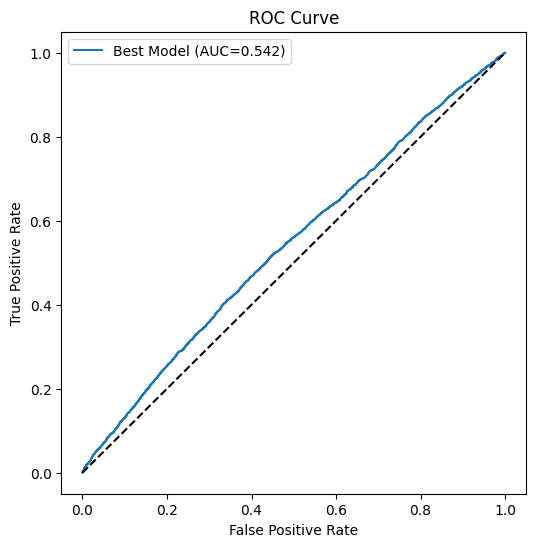

In [22]:
# Random forest
prob = best_model.predict_proba(data_frame)[:,1]
fpr, tpr, _ = roc_curve(y_train, prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC={roc_auc_score(y_train, prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 3.2 Confusion Matrix

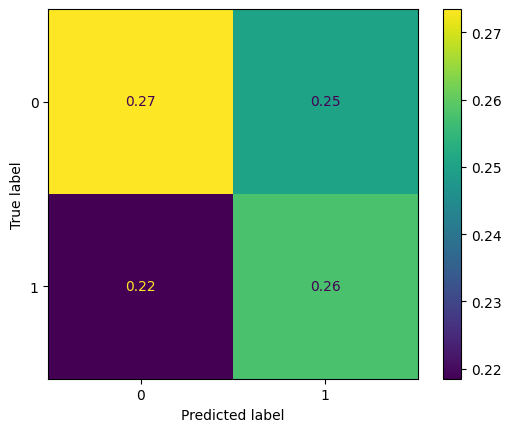

In [23]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    data_frame,
    y_train,
    normalize='all'
)

<Axes: xlabel='elo_diff', ylabel='Count'>

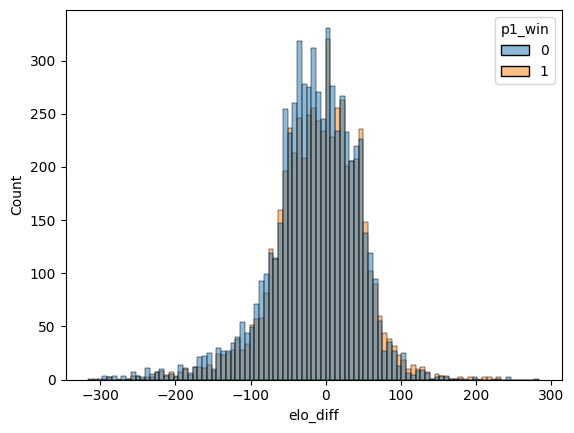

In [24]:
import seaborn as sns

sns.histplot(data=train_df, x='elo_diff', hue='p1_win')

In [25]:
train_df["predictions"] = best_model.predict(data_frame)

<Axes: xlabel='elo_diff', ylabel='Count'>

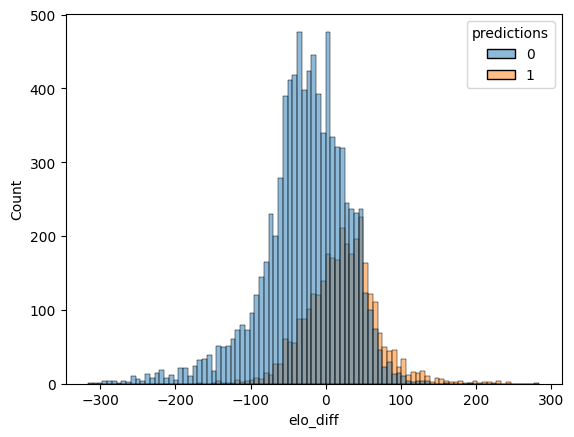

In [21]:
sns.histplot(data = train_df,x='elo_diff',hue='predictions')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

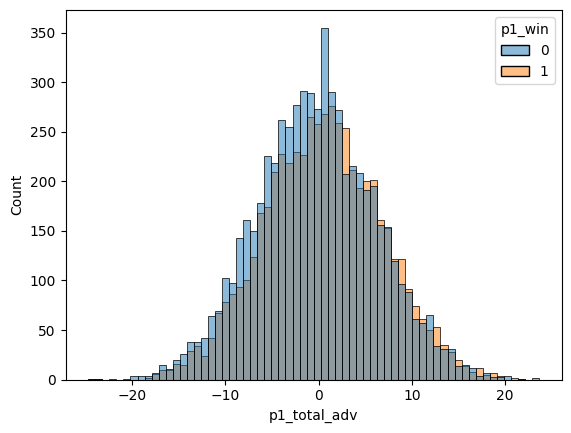

In [26]:
sns.histplot(data=train_df,x='p1_total_adv',hue='p1_win')

<Axes: xlabel='p1_total_adv', ylabel='Count'>

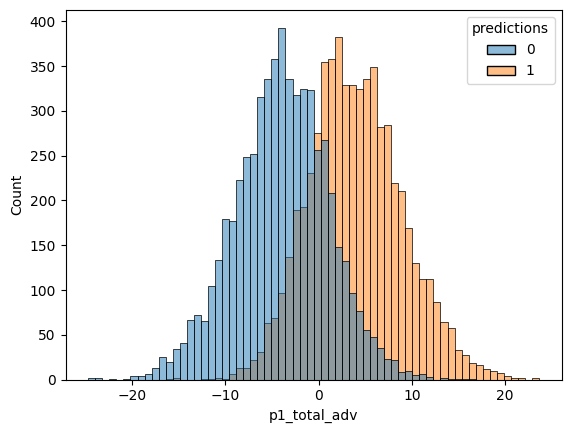

In [27]:
sns.histplot(data=train_df,x='p1_total_adv',hue='predictions')